# Steel: cooling curve in, microstructure out

*A guided what-if over the validated steel-production chain.*

You austenitize a steel, cool it, and ask **what material do I get** — soft and
machinable, or file-hard? This notebook walks that question end to end and lets
you **turn the knobs**: carbon, alloy grade, quench medium, section size, temper.

Every number here is produced by a function that is **validated in isolation**
(`projects/steel/…`, each with its own test triad). The notebook is a *thin
skin*: each compute cell calls the headless `sweep` / `properties` / `fe_c`
harness directly, then `ipywidgets` sliders re-run that same harness live. Per
[ADR 0002](../../docs/decisions/0002-visualization-and-ux.md) the figures
*consume* validated arrays — they are reach, not evidence.

The arc:

1. **The endpoint** — where carbon sends a *slowly-cooled* steel (`fe_c`).
2. **The mechanism** — the TTT C-curve, and why *how fast* you cool decides the
   microstructure (`sweep` → the four-curves anchor).
3. **Hardenability** — the composition axis: why an alloy steel hardens deeper.
4. **Tempering** — trading hardness back for toughness (Hollomon–Jaffe).

## Setup

Imports + the inline backend. The bootstrap walks up to the repo root so
`projects.steel…` imports whether you launched Jupyter from the repo root or
from `projects/steel/`. Needs the `viz` + `notebook` extras:
`pip install -e .[viz,notebook]`.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

# Make `projects.steel…` importable regardless of the launch directory.
for _root in (Path.cwd(), *Path.cwd().parents):
    if (_root / "pyproject.toml").exists():
        if str(_root) not in sys.path:
            sys.path.insert(0, str(_root))
        break

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

from projects.steel import fe_c, sweep
from projects.steel import properties as prop
from projects.steel.sweep import STEELS, DEFAULT_MEDIA
from projects.steel.plots import (
    four_curves_figure, sweep_comparison_figure,
    plot_ttt, plot_cooling_paths, plot_microstructure_bars,
    PHASE_COLORS, PHASE_LABELS,
)

GRADES = list(STEELS)            # 1045 / 1080 / 4140 / 8620 — real compositions
print("steels:", {k: STEELS[k].label() for k in GRADES})
print("media (slow → fast):", DEFAULT_MEDIA)

steels: {'1045': '1045', '1080': '1080', '4140': '4140', '8620': '8620'}
media (slow → fast): ('furnace', 'air', 'oil', 'water')


## 1 · The endpoint: where carbon takes a slowly-cooled steel

Cool a steel *slowly* (so it reaches equilibrium) to just below A₁ ≈ 727 °C and
the austenite has fully decomposed. **Carbon alone** sets what you get
([`fe_c.equilibrium_constituents`](fe_c.py)): below the eutectoid (0.76 %C) a
soft **pro-eutectoid ferrite** network around **pearlite** colonies; above it,
a brittle **pro-eutectoid cementite** network instead. This is the *equilibrium*
limit — minor alloying elements barely move it, so here (and only here) a bare
carbon knob is honest.

In [2]:
# Direct call — the worked example (AISI 1045, 0.45 %C).
c = fe_c.equilibrium_constituents(0.45)
print(f"0.45 %C, slow-cooled →  {c.f_proeutectoid:.0%} pro-eutectoid {c.proeutectoid}"
      f"  +  {c.f_pearlite:.0%} pearlite")
print(f"   phase totals:  {c.f_ferrite_total:.0%} ferrite   {c.f_cementite_total:.0%} cementite (Fe₃C)")

0.45 %C, slow-cooled →  42% pro-eutectoid ferrite  +  58% pearlite
   phase totals:  94% ferrite   6% cementite (Fe₃C)


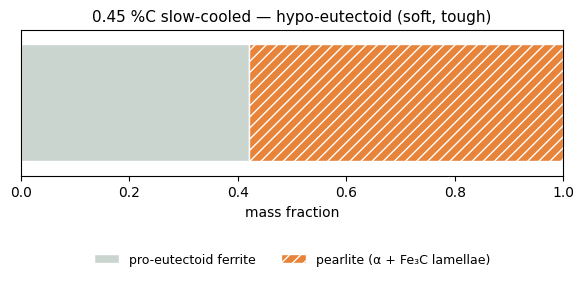

In [3]:
def show_equilibrium(carbon=0.45):
    # Slow-cooled constituents vs carbon — a direct fe_c.equilibrium_constituents call.
    c = fe_c.equilibrium_constituents(float(carbon))
    pro_color = PHASE_COLORS["pearlite"] if c.proeutectoid == "cementite" else "#cbd5d0"
    fig, ax = plt.subplots(figsize=(7, 1.9))
    ax.barh(0, c.f_proeutectoid, color=pro_color, edgecolor="white",
            label=f"pro-eutectoid {c.proeutectoid}")
    ax.barh(0, c.f_pearlite, left=c.f_proeutectoid, color=PHASE_COLORS["pearlite"],
            edgecolor="white", hatch="///", label="pearlite (α + Fe₃C lamellae)")
    ax.set_xlim(0, 1); ax.set_ylim(-0.5, 0.5); ax.set_yticks([])
    ax.set_xlabel("mass fraction")
    kind = "hypo-eutectoid (soft, tough)" if carbon < fe_c.C_EUTECTOID else \
           ("eutectoid (all pearlite)" if abs(carbon - fe_c.C_EUTECTOID) < 1e-9
            else "hyper-eutectoid (brittle Fe₃C network)")
    ax.set_title(f"{carbon:.2f} %C slow-cooled — {kind}", fontsize=11)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.45), ncol=2, frameon=False, fontsize=9)
    plt.show()

# Direct render (static, banked in the .ipynb).
show_equilibrium(0.45)

In [4]:
# Live: drag carbon across the eutectoid and watch the constituent network flip.
interact(show_equilibrium,
         carbon=widgets.FloatSlider(value=0.45, min=0.05, max=1.20, step=0.05,
                                    description="%C", continuous_update=False));

interactive(children=(FloatSlider(value=0.45, continuous_update=False, description='%C', max=1.2, min=0.05, st…

## 2 · The mechanism: the TTT C-curve and *how fast* you cool

Slow cooling reaches equilibrium; a real quench does not. Undercooling below A₁
is the **driving force**, but diffusion needs *time* — so the
time-to-transform traces a **C-curve** (fast at the warm/cold extremes, slowest
at the **nose**). A cooling path that **misses the nose** has no time to form
pearlite and instead shears to hard, diffusionless **martensite** below Mₛ. Same
austenite, a spectrum of fates, set entirely by which side of the nose the path
falls — the project's anchor result
([`demo_four_curves`](demo_four_curves.py)), here over any real grade.

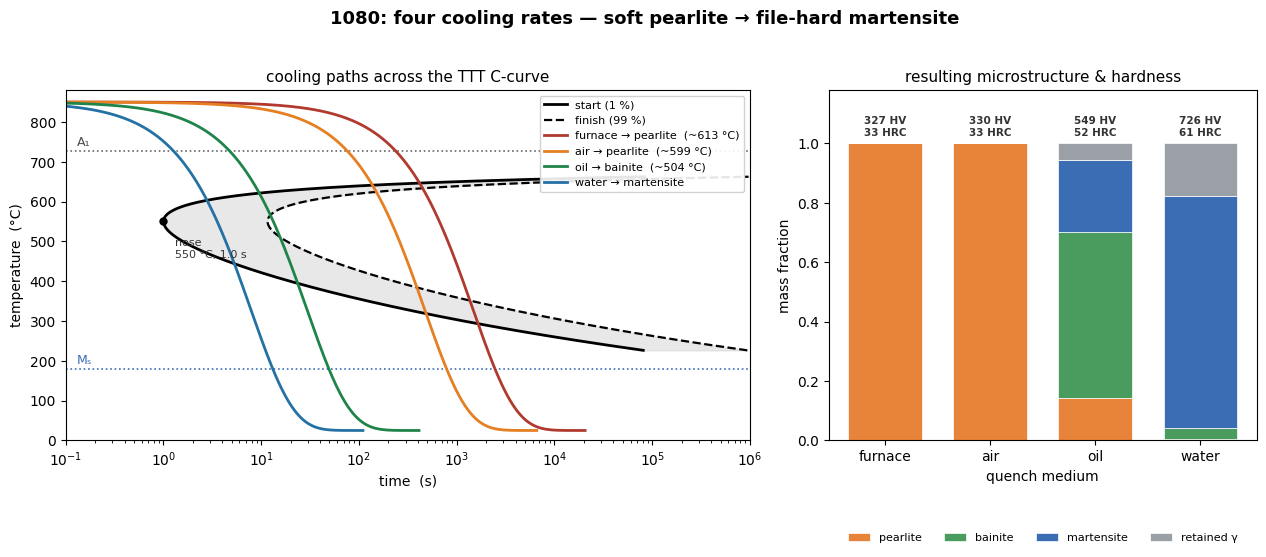

In [5]:
def four_curves(grade="1080"):
    # One steel, four quench rates across its TTT — direct sweep.cooling_rate_sweep.
    outs = sweep.cooling_rate_sweep(STEELS[grade], media=DEFAULT_MEDIA)
    fig = four_curves_figure(
        outs[0].ccurve,                       # same austenite → one C-curve
        [o.path for o in outs],
        [o.result for o in outs],
        hardness=[(o.HV, o.HRC) for o in outs],
        title=f"{STEELS[grade].label()}: four cooling rates — soft pearlite → file-hard martensite",
    )
    plt.show()

# Direct render (static, banked).
four_curves("1080")

In [6]:
interact(four_curves, grade=widgets.Dropdown(options=GRADES, value="1080", description="steel"));

interactive(children=(Dropdown(description='steel', index=1, options=('1045', '1080', '4140', '8620'), value='…

### Drag a single path across the C-curve

Pick one steel, one medium, one **section size** and watch *that* path fall
across the C-curve into its microstructure. Thicken the section or pick a steel
whose hardenability can't keep up and martensite gives way to pearlite. A severe
quench of a thick section trips the **Biot flag** — the honest cue that the 0-D
lumped cooler is stretched and the [Phase-2 spatial Jominy solve](jominy.py) is
what you actually want there.

4140  oil  10 mm  →  martensite   632 HV / 57 HRC


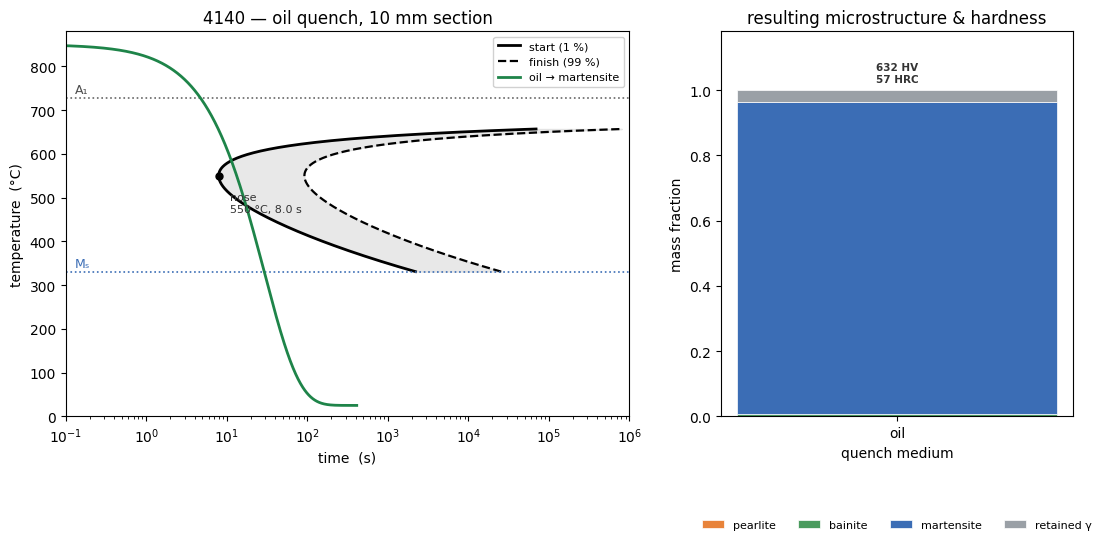

In [7]:
def what_if(grade="4140", medium="oil", section_mm=10.0):
    # One (steel, medium, section) what-if — a direct sweep.evaluate call.
    o = sweep.evaluate(STEELS[grade], medium=medium, diameter=float(section_mm) / 1000.0)
    fig, (ax_ttt, ax_bar) = plt.subplots(
        1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1.6, 1.0]})
    plot_ttt(ax_ttt, o.ccurve)
    plot_cooling_paths(ax_ttt, [o.path], [o.result])
    ax_ttt.set_title(f"{STEELS[grade].label()} — {medium} quench, {section_mm:.0f} mm section")
    plot_microstructure_bars(ax_bar, [o.path], [o.result], hardness=[(o.HV, o.HRC)])
    ax_bar.set_title("resulting microstructure & hardness")
    hrc = f"{o.HRC:.0f} HRC" if np.isfinite(o.HRC) else "off HRC scale (soft)"
    flag = "" if o.lumped_valid else f"   ⚠ Bi = {o.biot:.2f} ≥ 0.1 → 0-D stretched (use the Jominy spatial solve)"
    print(f"{STEELS[grade].label()}  {medium}  {section_mm:.0f} mm  →  "
          f"{o.dominant().replace('_', ' ')}   {o.HV:.0f} HV / {hrc}{flag}")
    plt.show()

# Direct render (static, banked).
what_if("4140", "oil", 10.0)

In [8]:
interact(
    what_if,
    grade=widgets.Dropdown(options=GRADES, value="4140", description="steel"),
    medium=widgets.Dropdown(options=list(DEFAULT_MEDIA), value="oil", description="quench"),
    section_mm=widgets.FloatSlider(value=10.0, min=5.0, max=80.0, step=5.0,
                                   description="section mm", continuous_update=False),
);

interactive(children=(Dropdown(description='steel', index=2, options=('1045', '1080', '4140', '8620'), value='…

## 3 · Hardenability: the composition axis

The four-curves view fixes the steel and sweeps the rate. Flip it: fix the rate,
sweep the **composition**. Mn/Cr/Mo slide the whole C-curve to longer times, so
martensite survives a **slower** quench — the steel hardens **deeper**.

One honesty note baked into the 0-D model: a quench medium feeds *every* steel
the **same** cooling path (the lumped `T(t)` depends on the section and medium,
not composition), so the steels **share the martensitic fast end (water) and the
pearlitic slow end (furnace) and diverge only in the middle**. Read the alloy
trend at an *intermediate* medium (oil) — never at the saturated ends, where the
composition axis is silent.

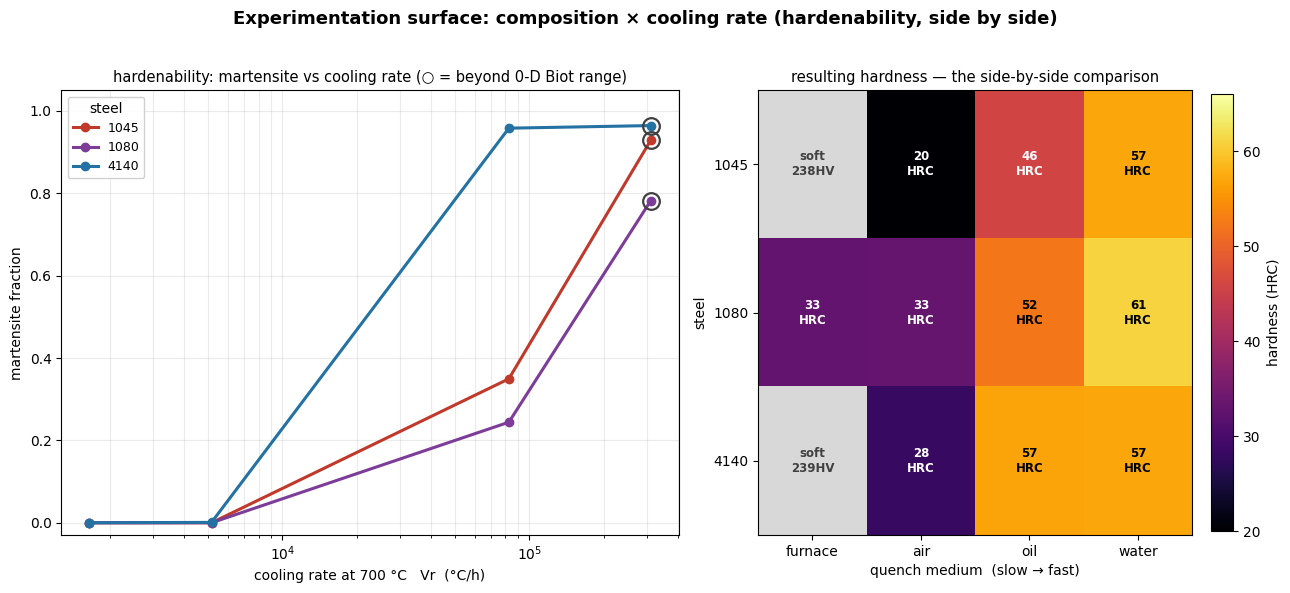

In [9]:
def compare(grades=("1045", "1080", "4140")):
    # Composition × cooling-rate grid — a direct sweep.sweep_grid call.
    grades = list(grades)
    if len(grades) < 2:
        print("pick at least two steels to compare"); return
    grid = sweep.sweep_grid(grades, media=DEFAULT_MEDIA)
    fig = sweep_comparison_figure(grid)
    plt.show()

# Direct render (static, banked).
compare(("1045", "1080", "4140"))

In [10]:
interact(
    compare,
    grades=widgets.SelectMultiple(options=GRADES, value=("1045", "1080", "4140"),
                                  description="steels", rows=4),
);

interactive(children=(SelectMultiple(description='steels', index=(0, 1, 2), options=('1045', '1080', '4140', '…

## 4 · Tempering: trading hardness back for toughness

As-quenched martensite is hard but brittle — almost every real part is then
**tempered** (reheated, sub-A₁) to recover toughness at some cost in hardness.
The **Hollomon–Jaffe** parameter `P = T·(C + log₁₀ t)` collapses temperature and
time into one knob; hardness slides down a master curve as `P` rises, and
strength/toughness follow ([`properties`](properties.py), §3b). This is the
**martensite-only** quench-and-temper response (the validated scope), so it gets
its own sweep — an alloy steel **resists softening** as an emergent consequence
of starting harder *and* flooring higher.

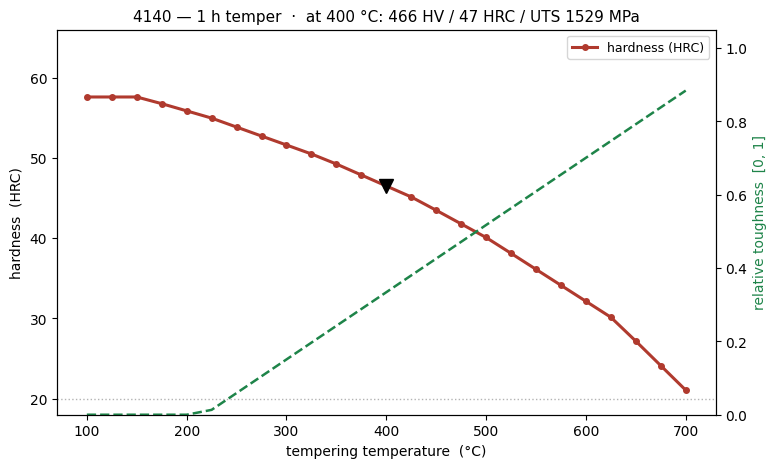

In [11]:
def temper(grade="4140", t_hours=1.0, mark_T=400.0):
    # Quench-and-temper response — direct sweep.temper_sweep + a properties readout.
    steel = STEELS[grade]
    tr = sweep.temper_sweep(steel, t_hours=float(t_hours))
    finite = np.isfinite(tr.HRC)

    fig, ax = plt.subplots(figsize=(8.5, 5))
    ax.plot(tr.temper_C[finite], tr.HRC[finite], "-o", color="#b03a2e", ms=4, lw=2.2,
            label="hardness (HRC)")
    ax.axhline(prop.RELIABLE_HRC_MIN, color="0.7", ls=":", lw=1.0)
    ax.set_xlabel("tempering temperature  (°C)"); ax.set_ylabel("hardness  (HRC)")
    ax.set_ylim(prop.RELIABLE_HRC_MIN - 2, 66)
    ax_t = ax.twinx()
    ax_t.plot(tr.temper_C, tr.toughness, "--", color="#1e8449", lw=1.8, label="toughness (rel.)")
    ax_t.set_ylabel("relative toughness  [0, 1]", color="#1e8449"); ax_t.set_ylim(0, 1.05)

    # The marked point — a direct properties call (not interpolated from the sweep).
    HV = prop.tempered_martensite_HV(steel.C, float(mark_T), float(t_hours), comp=steel.minor())
    HRC = prop.vickers_to_rockwell_c(HV)
    UTS = prop.tensile_strength_MPa(HV)
    if np.isfinite(HRC):
        ax.plot([mark_T], [HRC], "kv", ms=10, zorder=5)
    uts_s = f"{UTS:.0f} MPa" if np.isfinite(UTS) else "off-scale (HV > ~550)"
    hrc_s = f"{HRC:.0f} HRC" if np.isfinite(HRC) else "off HRC scale"
    ax.set_title(f"{steel.label()} — {t_hours:g} h temper  ·  at {mark_T:.0f} °C: "
                 f"{HV:.0f} HV / {hrc_s} / UTS {uts_s}", fontsize=11)
    ax.legend(loc="upper right", fontsize=9)
    plt.show()

# Direct render (static, banked).
temper("4140", 1.0, 400.0)

In [12]:
interact(
    temper,
    grade=widgets.Dropdown(options=GRADES, value="4140", description="steel"),
    t_hours=widgets.FloatSlider(value=1.0, min=0.25, max=10.0, step=0.25,
                                description="time (h)", continuous_update=False),
    mark_T=widgets.FloatSlider(value=400.0, min=100.0, max=700.0, step=25.0,
                               description="temper °C", continuous_update=False),
);

interactive(children=(Dropdown(description='steel', index=2, options=('1045', '1080', '4140', '8620'), value='…

## Where the numbers come from

Nothing above is computed *here*. Each slider re-runs the headless
[`sweep`](sweep.py) harness — itself **pure re-composition** of the validated
chain `ccurve_for_steel → cooling → pathint → properties` — and every constituent
hardness, kinetic constant, and tempering breakpoint is anchored and tested in
its own module. The shareable Streamlit twin of this surface is **slice 2**
(`app.py`); the headless artifact both wrap is [`demo_sweep`](demo_sweep.py).

> **Scope, stated honestly.** The cooling histories are 0-D lumped-capacitance
> (the Biot flag fires when that's stretched); hardness is compared in **HV**
> (defined everywhere; HRC is `nan` below ~20 HRC); tempering is
> **martensite-only**. These are the same edges the harness docstrings carry —
> surfaced, not hidden.